## Read cross-validation results to select the best-performing model and representation

In [1]:
import os 
import pickle 
import pandas as pd
import altair as alt

In [2]:
# GLOBAL VARIABLES
FOLDER_EVAL_PER_FOLD = "./outputs/eval_per_fold"
FOLDER_TEST_DATA = "./dataset/test_folder"
FOLDER_CROSSVAL = "./outputs/crossval" #crossval_wo_deduplication
FOLDER_PREV_STUDIES = "./dataset/prev_studies"

eval_metrics = ['accuracy','mcc','f1','precision','recall',
                'true_positive','true_negative','false_positive','false_negative']

In [3]:
# read cross-validation results
files = [f for f in os.listdir(FOLDER_CROSSVAL) if os.path.isfile(os.path.join(FOLDER_CROSSVAL, f))]

final_df = pd.DataFrame()

for file in files:
    # find only excel files ending with .xlsx
    if file.endswith('.xlsx'):
        filename = os.path.join(FOLDER_CROSSVAL,file)
        df = pd.read_excel(filename)
        # assign subcase to the dataframe from the filename {subcase}_crossval.xlsx
        df['subcase'] = file.split('_crossval')[0].removeprefix('deduplicated_')
        final_df = pd.concat([final_df,df])

final_df['case'] = final_df['subcase'].apply(lambda x: x.split('_')[0])

# 
eval_metrics = ['accuracy','mcc','f1','precision','recall',
                'true_positive','true_negative','false_positive','false_negative']

summary_df = final_df.groupby(['case','subcase','pair_id'])[eval_metrics].agg(['mean','std'])
# Optional: Flatten the MultiIndex columns for easier exporting/reading
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()
summary_df[['representation','model']] = summary_df['pair_id'].str.split('/', expand=True)

#filter model to only include SVM, Random Forest, Logistic Regression, Naive Bayes, and Decision Tree
summary_df = summary_df[summary_df['model'].isin(['SVM','RandomForest','LogisticRegression','NaiveBayes','DecisionTree'])]

In [4]:
metric = 'f1'

# rank_per_representation shows the rank for the best model per representation
kmer_family = summary_df[(summary_df.representation.str.contains('Kmer'))].copy()
kmer_family['kmer'] = kmer_family['representation'].str.split('-',n=1).str[0]
kmer_family['rank_per_representation'] = kmer_family.groupby(['subcase','kmer'])[f'{metric}_mean'].rank(method="first", ascending=False)

non_kmer_summary_df = summary_df[~(summary_df.representation.str.contains('Kmer'))].copy()
non_kmer_summary_df['rank_per_representation'] = non_kmer_summary_df.groupby(['subcase','representation'])[f'{metric}_mean'].rank(method="first", ascending=False)

#assign the rank of RCKmer and Kmer to the original table
#df_merged = pd.merge(summary_df, kmer_family[['subcase','representation','model','rank_per_representation']], on=['subcase','representation','model'], how='left')
#df_merged = df_merged.fillna(1.0)
df_merged = pd.concat([non_kmer_summary_df, kmer_family], ignore_index=True)

#select the best model for each representation and for RCKmer and Kmer, select only the best k
top_model_rep_df = df_merged[df_merged['rank_per_representation']==1].copy()

# show the top 5 performing representations along with the corresponding model sorted by F_1 score in descending order
top_results = top_model_rep_df.groupby(['case','subcase']).apply(pd.DataFrame.nlargest, n=5, columns=[f'{metric}_mean'])
# assign rank 
top_results = top_results.reset_index(drop=True)
top_results['rank_per_subcase'] = top_results.groupby(['subcase'])[f'{metric}_mean'].rank(method="first", ascending=False)

final_df_w_rank = pd.merge(final_df, top_results[['subcase','pair_id','rank_per_subcase']], on=['subcase','pair_id'], how='inner')
final_df_w_rank['pair_id'] = final_df_w_rank['pair_id'].str.replace("RandomForest","RF")

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_54128/2840561629.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_results = top_model_rep_df.groupby(['case','subcase']).apply(pd.DataFrame.nlargest, n=5, columns=[f'{metric}_mean'])


In [5]:
# visualize the top 5 models and representations for each training case
chart = alt.vconcat()

subcharts = []
cases = ['case1', 'case2a', 'case2b', 'case3']
for case in cases:
    subcases = final_df_w_rank[final_df_w_rank['case']==case].subcase.unique()
    subcases = sorted(subcases)
    subcharts = alt.hconcat()

    for subcase in subcases:
        temp_df = final_df_w_rank[final_df_w_rank['subcase']==subcase]
        sorted_label = temp_df[['case','pair_id','rank_per_subcase']].drop_duplicates()
        sorted_label = sorted_label.sort_values(by='rank_per_subcase').pair_id.to_list()

        subchart = alt.Chart(temp_df).mark_boxplot(color='gray').encode(
                            x=alt.X("pair_id:N", sort=sorted_label, title=None, axis=alt.Axis(labelAngle=-30)),
                            y=alt.Y(f"{metric}:Q", title=None, scale=alt.Scale(domain=[0.4,1])),
                            #column=alt.Column("case:N", title=None)
                        ).properties(
                            title=subcase,
                            width=200,
                            height=200,
                        )
        
        subcharts |= subchart
    
    subcharts = subcharts
    chart &= subcharts

fontsize = 12
chart = chart.configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_header(
    labelFontSize=fontsize
)
chart

alt.VConcatChart(...)

In [6]:
#chart.save("figures/crossval_boxplot_by_case_wo_deduplication.pdf")

### Statistical analysis

In [7]:
## statistical test per case to see the significance of the difference between models in each training case
from scipy.stats import friedmanchisquare
from itertools import combinations
from scipy.stats import wilcoxon

subcases = final_df_w_rank.subcase.unique()
subcases = sorted(subcases)

posthoc_df = pd.DataFrame()

for subcase in subcases:
    sub_df = final_df_w_rank[final_df_w_rank['subcase'] == subcase]
    f1_matrix = sub_df.pivot(index="fold", columns="rank_per_subcase", values="f1")
    stat, p = friedmanchisquare(*[f1_matrix[c] for c in f1_matrix.columns])
    print(f"{subcase}: Friedman χ² = {stat:.3f}, p = {p}")

    results = []

    for m1, m2 in combinations(f1_matrix.columns, 2):
        stat, p = wilcoxon(f1_matrix[m1], f1_matrix[m2])
        results.append((m1, m2, p))

    posthoc = pd.DataFrame(results, columns=['model_1', 'model_2', 'p_value'])
    posthoc['subcase'] = subcase

    posthoc_df = pd.concat([posthoc_df, posthoc])
    
    # n_blocks, n_train = f1_matrix.shape
    # kendalls_w = stat / (n_blocks * (n_train - 1))
    # print(f"Kendall's W = {kendalls_w:.3f}")

case1_1: Friedman χ² = 62.996, p = 6.799115586224146e-13
case1_2: Friedman χ² = 61.440, p = 1.4447965455084415e-12
case1_3: Friedman χ² = 75.104, p = 1.89417686900207e-15
case1_4: Friedman χ² = 80.480, p = 1.378188763736268e-16
case1_5: Friedman χ² = 82.304, p = 5.65889539800401e-17
case2a_1: Friedman χ² = 48.032, p = 9.293976945640927e-10
case2a_2: Friedman χ² = 69.888, p = 2.3968454421857984e-14
case2a_3: Friedman χ² = 74.656, p = 2.3559807485008854e-15
case2a_4: Friedman χ² = 75.968, p = 1.2434971600862394e-15
case2a_5: Friedman χ² = 78.592, p = 3.4611942772484794e-16
case2b_1: Friedman χ² = 56.072, p = 1.9365398588909372e-11
case2b_2: Friedman χ² = 73.536, p = 4.064288017263533e-15
case2b_3: Friedman χ² = 78.368, p = 3.8606300453939714e-16
case2b_4: Friedman χ² = 78.870, p = 3.022802174374904e-16
case2b_5: Friedman χ² = 75.936, p = 1.2630345410551126e-15
case3_1: Friedman χ² = 68.704, p = 4.2611806498927226e-14
case3_2: Friedman χ² = 77.056, p = 7.31824664162092e-16
case3_3: Friedm

In [8]:
# for each subcase, check if there is no statistical different between the best model and the other models
# if p-values > 0.05, then the difference between the best model and the other models is not statistically significant
# there is no statistical difference between the best model and the second best model
posthoc_df[(posthoc_df['p_value']>0.001) & (posthoc_df['model_1']==1)]

,model_1,model_2,p_value,subcase
0,1.0,2.0,0.116083,case1_1
0,1.0,2.0,0.085139,case1_2
1,1.0,3.0,0.010511,case1_2
0,1.0,2.0,0.200216,case1_3
0,1.0,2.0,0.020275,case1_4
0,1.0,2.0,0.832509,case1_5
0,1.0,2.0,0.410765,case2a_1
1,1.0,3.0,0.006129,case2a_1
0,1.0,2.0,0.012466,case2a_2
0,1.0,2.0,0.002508,case2a_3


## Visualize cross-validation results of the best model and representation

In [9]:
best_cv = final_df_w_rank[final_df_w_rank['pair_id']=="RCKmer-7/SVM"]
best_cv.rename(columns={'case':'train_group', 'subcase':'train_case'}, inplace=True)
best_cv.head()

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_54128/3228755350.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_cv.rename(columns={'case':'train_group', 'subcase':'train_case'}, inplace=True)


,fold,pair_id,mcc,f1,precision,recall,accuracy,true_positive,true_negative,false_positive,false_negative,train_case,train_group,rank_per_subcase
1,fold_0,RCKmer-7/SVM,0.694748,0.846300,0.805054,0.892000,0.845124,223,219,54,27,case2b_3,case2b,1.0
6,fold_1,RCKmer-7/SVM,0.792478,0.892250,0.897338,0.887218,0.896364,236,257,27,30,case2b_3,case2b,1.0
11,fold_2,RCKmer-7/SVM,0.681805,0.836957,0.840000,0.833935,0.840989,231,245,44,46,case2b_3,case2b,1.0
16,fold_3,RCKmer-7/SVM,0.726983,0.853175,0.899582,0.811321,0.861940,215,247,24,50,case2b_3,case2b,1.0
21,fold_4,RCKmer-7/SVM,0.479774,0.746365,0.631148,0.913043,0.712454,231,158,135,22,case2b_3,case2b,1.0


In [10]:
score_domain = [0,1]

# 1. Melt to get metrics (f1, mcc) into one column (all_eval_res[all_eval_res['test_group']=='deduplicated'])
df_long = best_cv.melt(
    id_vars=['train_group', 'train_case'], 
    value_vars=['f1', 'precision', 'recall', 'mcc', 'accuracy'], 
    var_name='metric', 
    value_name='score'
)

# 2. Calculate Min and Max per pair of Group A/B and Metric
# This creates the 'lower' and 'upper' columns based on your real data spread
stats = df_long.groupby(['train_group', 'train_case', 'metric'])['score'].agg(['std', 'mean']).reset_index()
stats.columns = ['train_group', 'train_case','metric', 'std', 'score']
stats['upper'] = stats['score'] + stats['std']
stats['lower'] = stats['score'] - stats['std']


train_groups = ['case1','case2a','case2b','case3']

final_charts = []

for metric in ['f1', 'precision', 'recall', 'mcc', 'accuracy']:
    subcharts = []

    for train_group in train_groups:
        # Create the base chart
        base = alt.Chart(stats[(stats['train_group']==train_group) & (stats['metric']==metric)]).encode(
            x=alt.X('train_case:N', axis=alt.Axis(labelAngle=30, title="Training case")),
            #color=alt.Color('metric:N', scale=color_scale, title="Performance Metric")
        )

        # The Area Layer: Uses the actual min/max from your data
        area = base.mark_area(opacity=0.25, color='gray').encode(
            y=alt.Y('lower:Q', axis=alt.Axis(title=None)),
            y2='upper:Q',
            # Ensure Group B is separated if you have multiple B groups per A
            #detail='train_case:N' 
            detail='metric:N',
            tooltip=['lower','upper','score','std']
        )

        # The Line Layer: Representing the average or trend
        line = base.mark_line(color='gray').encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None), scale=alt.Scale(domain=score_domain)),
            #strokeDash=alt.StrokeDash('metric:N', title="Performance Metrics")
            detail='metric:N'
        )

        shape_scale = alt.Scale(
            domain=['f1', 'precision', 'recall', 'mcc', 'accuracy'],
            range=['square', 'circle', 'triangle-up', 'diamond', 'cross']
        )

        # The Points Layer
        points = base.mark_point(
            color='black', 
            filled=True, 
            size=60
        ).encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None), scale=alt.Scale(domain=score_domain)),
            shape=alt.Shape('metric:N', scale=shape_scale, title="Evaluation Metrics",
                            legend=alt.Legend(
                                # This logic renames the labels specifically in the legend
                                labelExpr="datum.label == 'f1' ? 'F1 score' : datum.label == 'precision' ? 'Precision' : datum.label == 'recall' ? 'Recall' : datum.label == 'mcc' ? 'MCC' : datum.label == 'accuracy' ? 'Accuracy' : datum.label"
                            ))
        )

        chart = (area + line + points).properties(
            width=200,
            height=150
        )

        subcharts.append(chart)
    grid = (subcharts[0] | subcharts[1] | subcharts[2] | subcharts[3])
    final_charts.append(grid)

fontsize = 14
#grid = (subcharts[0] | subcharts[1] | subcharts[2] | subcharts[3])
grid = (final_charts[0] & final_charts[1] & final_charts[2] & final_charts[3] & final_charts[4])
grid = grid.resolve_legend(
    color="shared",
).configure_legend(
    orient="top",
    titleFontSize=fontsize,   
    labelFontSize=fontsize,
).configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_header(
    labelFontSize=fontsize
) 

grid

alt.VConcatChart(...)

In [11]:
#grid.save("./figures/deduplicated_best_cv.pdf") #save the cv on deduplicated training data

### Statistical analysis

In [12]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

train_groups = best_cv.train_group.unique()
train_groups = sorted(train_groups)

posthoc_df = pd.DataFrame()

for train_group in train_groups:
    sub_df = best_cv[best_cv['train_group'] == train_group]
    f1_matrix = sub_df.pivot(index="fold", columns="train_case", values="f1")
    stat, p = friedmanchisquare(*[f1_matrix[c] for c in f1_matrix.columns])
    print(f"{train_group}: Friedman χ² = {stat:.3f}, p = {p}")

    stat, p = kruskal(*[f1_matrix[c] for c in f1_matrix.columns])
    print(f'H = {stat:.3f}, p = {p}')

    # After significant Kruskal-Wallis
    pvals = posthoc_dunn(sub_df, val_col='f1', group_col='train_case', p_adjust='bonferroni')
    print(pvals)

case1: Friedman χ² = 26.656, p = 2.3329676571204277e-05
H = 27.016, p = 1.9734329846522557e-05
          case1_1   case1_2   case1_3   case1_4   case1_5
case1_1  1.000000  0.482430  0.066677  0.000491  0.000031
case1_2  0.482430  1.000000  1.000000  0.371127  0.072383
case1_3  0.066677  1.000000  1.000000  1.000000  0.514273
case1_4  0.000491  0.371127  1.000000  1.000000  1.000000
case1_5  0.000031  0.072383  0.514273  1.000000  1.000000
case2a: Friedman χ² = 40.096, p = 4.134995696355032e-08
H = 43.324, p = 8.862572877046801e-09
              case2a_1  case2a_2  case2a_3  case2a_4      case2a_5
case2a_1  1.000000e+00  0.063600  0.000017  0.000001  3.248142e-07
case2a_2  6.359979e-02  1.000000  0.398550  0.105030  5.127928e-02
case2a_3  1.719523e-05  0.398550  1.000000  1.000000  1.000000e+00
case2a_4  1.240436e-06  0.105030  1.000000  1.000000  1.000000e+00
case2a_5  3.248142e-07  0.051279  1.000000  1.000000  1.000000e+00
case2b: Friedman χ² = 42.496, p = 1.3164422871291107e-08
H = 

## Read evaluation results on holdout, deduplicated holdout, proMGE, and ATB data sets

In [13]:
def draw_bar_chart_per_training_case(summary_df, fontsize=14, 
                                     metric="f1", metrics_name="F1 score",
                                     test_cases=['in_species', 'out_species','out_genera_in_families','out_genera_out_families','out_phylum'],
                                     color_range=['#a6cee3','#1f78b4','#b2df8a','#33a02c','gray'],
                                     score_domain=[0,1]):
    cases = ['case1', 'case2a', 'case2b', 'case3']

    chart = alt.vconcat()

    subcharts = []

    for case in cases:
        subchart = alt.Chart(summary_df[summary_df['train_case'].str.contains(case)]).mark_bar().encode(
                            x=alt.X("train_case:N", title="Training case", axis=alt.Axis(labelAngle=0)),
                            xOffset=alt.XOffset("test_case:N", sort=test_cases),
                            y=alt.Y(f"{metric}:Q", title=metrics_name, scale=alt.Scale(domain=score_domain)),
                            color=alt.Color('test_case:N', title="Test case", 
                                            scale=alt.Scale(domain=test_cases,
                                                            range=color_range)),
                            tooltip=["train_case", "test_case", metric]
                        ).properties(
                            width=400,
                            height=200
                        )
        subcharts.append(subchart)
        chart &= subchart

    grid = (subcharts[0] | subcharts[1]) & (subcharts[2] | subcharts[3])# & (subcharts[2] | subcharts[3])
    grid = grid.resolve_legend(
        color="shared"
    ).configure_legend(
        orient="top",
        titleFontSize=fontsize,    
        labelFontSize=fontsize,
    ).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize,
    ).configure_header(
        labelFontSize=fontsize
    ) 

    return grid

# def draw_boxplot(summary_df, fontsize=12, 
#                  metric="f1", metrics_name="F1 score",
#                  test_cases=['in_species', 'out_species','out_genera_in_families','out_genera_out_families','out_phylum'],
#                  color_range=['#a6cee3','#1f78b4','#b2df8a','#33a02c','gray'],
#                  score_domain=[0.6,1]):
#     boxplot = alt.Chart(summary_df).mark_boxplot(
#         color='gray'
#     ).encode(
#         y=alt.Y("test_case:N", title="Test case", sort=test_cases),
#         x=alt.X(f"{metric}:Q", title=metrics_name, scale=alt.Scale(domain=score_domain)),
#         color=alt.Color('test_case:N', title="Test case", 
#                                             scale=alt.Scale(domain=test_cases,
#                                                             range=color_range), legend=None),
        
#         tooltip=["test_case", metric]
#     ).properties(
#         width=400,
#         height=100
#     ).configure_axis(
#         labelFontSize=fontsize,
#         titleFontSize=fontsize,
#     ).configure_header(
#         labelFontSize=fontsize
#     ) 

#     return boxplot

def draw_boxplot(summary_df, 
                 metric="f1", metrics_name="F1 score",
                 test_cases=['in_species', 'out_species','out_genera_in_families','out_genera_out_families','out_phyla'],
                 color_range=['#a6cee3','#1f78b4','#b2df8a','#33a02c','gray'],
                 score_domain=[0.6,1],
                 y_axis=True):
    
    if y_axis:
        boxplot = alt.Chart(summary_df).mark_boxplot(
            color='gray'
        ).encode(
            y=alt.Y("test_case:N", title="Test case", sort=test_cases, ),
            x=alt.X(f"{metric}:Q", title=metrics_name, scale=alt.Scale(domain=score_domain)),
            color=alt.Color('test_case:N', title="Test case", 
                                                scale=alt.Scale(domain=test_cases,
                                                                range=color_range), legend=None),
            
            #tooltip=["test_case", metric]
        ).properties(
            width=300,
            height=200
        )
    else:
        boxplot = alt.Chart(summary_df).mark_boxplot(
            color='gray'
        ).encode(
            y=alt.Y("test_case:N", title="Test case", sort=test_cases, axis=alt.Axis(labels=False, ticks=False, title=None)),
            x=alt.X(f"{metric}:Q", title=metrics_name, scale=alt.Scale(domain=score_domain)),
            color=alt.Color('test_case:N', title="Test case", 
                                                scale=alt.Scale(domain=test_cases,
                                                                range=color_range), legend=None),

        ).properties(
            width=300,
            height=200
        )

    return boxplot

### Read hyperparameter tuning results and evaluation results with the best hyperparameters

In [14]:
all_cv_res = pd.DataFrame()
all_eval_res = pd.DataFrame()

hpo_folder = "hpo_svm"

for file in os.listdir(hpo_folder):
    hpo_res = pickle.load(open(f'{hpo_folder}/{file}','rb'))

    filename = file.removesuffix('.pkl')
    best_idx = hpo_res[filename]['best_index']

    # read cv results

    cv_res = pd.DataFrame(hpo_res[filename]['cv_results'])
    cv_res = cv_res.reset_index()
    cv_res.rename(columns={'index':'param_id'},inplace=True)

    param_dict = cv_res.set_index('param_id')['params'].to_dict()

    # Auto-detect columns
    f1_cols = [col for col in cv_res if 'split' in col and '_test_f1' in col]
    recall_cols = [col for col in cv_res if 'split' in col and '_test_Recall' in col]
    precision_cols = [col for col in cv_res if 'split' in col and '_test_Precision' in col]
    mcc_cols = [col for col in cv_res if 'split' in col and '_test_MCC' in col]
    acc_cols = [col for col in cv_res if 'split' in col and '_test_Accuracy' in col]
    tp_cols = [col for col in cv_res if 'split' in col and '_test_TP' in col]
    tn_cols = [col for col in cv_res if 'split' in col and '_test_TN' in col]
    fp_cols = [col for col in cv_res if 'split' in col and '_test_FP' in col]
    fn_cols = [col for col in cv_res if 'split' in col and '_test_FN' in col]

    # Melt to long format
    f1_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=f1_cols,
                    var_name='split', value_name='f1')
    f1_long['split'] = f1_long['split'].str.extract(r'split(\d+)')[0]

    precision_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=precision_cols, 
                        var_name='split', value_name='precision')
    precision_long['split'] = precision_long['split'].str.extract(r'split(\d+)')[0]

    recall_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=recall_cols, 
                        var_name='split', value_name='recall')
    recall_long['split'] = recall_long['split'].str.extract(r'split(\d+)')[0]

    mcc_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=mcc_cols, 
                        var_name='split', value_name='mcc')
    mcc_long['split'] = mcc_long['split'].str.extract(r'split(\d+)')[0]

    tp_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=tp_cols, 
                        var_name='split', value_name='tp')
    tp_long['split'] = tp_long['split'].str.extract(r'split(\d+)')[0]

    tn_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=tn_cols, 
                        var_name='split', value_name='tn')
    tn_long['split'] = tn_long['split'].str.extract(r'split(\d+)')[0]

    fp_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=fp_cols, 
                        var_name='split', value_name='fp')
    fp_long['split'] = fp_long['split'].str.extract(r'split(\d+)')[0]

    fn_long = pd.melt(cv_res, id_vars=['param_id'], value_vars=fn_cols, 
                        var_name='split', value_name='fn')
    fn_long['split'] = fn_long['split'].str.extract(r'split(\d+)')[0]

    # Merge on params + split
    long_df = pd.merge(f1_long, recall_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, precision_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, mcc_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, tp_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, tn_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, fp_long, on=['param_id', 'split'])
    long_df = pd.merge(long_df, fn_long, on=['param_id', 'split'])

    long_df['params'] = long_df['param_id'].map(param_dict)
    long_df['best_idx'] = best_idx
    long_df['train_data'] = filename

    all_cv_res = pd.concat([all_cv_res, long_df], ignore_index=True)



    # evaluation results
    eval_res = pd.DataFrame.from_dict(hpo_res[filename]['eval_scores'], orient='index')
    eval_res = eval_res.reset_index().rename(columns={'index':'id'})
    eval_res['train_case'] = eval_res['id'].apply(lambda x: x.split('/')[0].removeprefix('deduplicated_'))
    eval_res['train_group'] = eval_res['train_case'].apply(lambda x: x.split('_')[0])
    eval_res['test_case'] = eval_res['id'].apply(lambda x: x.split('/')[1])
    eval_res['test_group'] = eval_res['test_case'].apply(lambda x:x.split('_')[0] if x.startswith(('promge','ATB','deduplicated')) else 'holdout')
    eval_res['test_case'] = eval_res.apply(lambda x:x['test_case'].removeprefix(f"{x['test_group']}_"), axis=1)
    #eval_res.sort_values(by='f1', ascending=False)

    all_eval_res = pd.concat([all_eval_res, eval_res], ignore_index=True)

all_cv_res['accuracy'] = (all_cv_res['tp'] + all_cv_res['tn']) / (all_cv_res['tp'] + all_cv_res['tn'] + all_cv_res['fp'] + all_cv_res['fn'])
all_eval_res.columns = [col.lower() for col in all_eval_res.columns]
all_eval_res = all_eval_res[~all_eval_res['test_case'].str.contains('in_phylum')]

In [15]:
all_cv_res[all_cv_res['best_idx']==all_cv_res['param_id']]['params'].value_counts()

params
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}     70
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}    30
Name: count, dtype: int64

### Select the best hyperparameters for each training case

In [16]:
best_cv_hpo = all_cv_res[all_cv_res['best_idx']==all_cv_res['param_id']][['train_data','split','f1','recall','precision','mcc', 'accuracy']]
best_cv_hpo['train_data'] = best_cv_hpo['train_data'].str.removeprefix('deduplicated_')
best_cv_hpo['train_case'] = best_cv_hpo['train_data'].str.removesuffix('_SVM_RCKmer-7')
best_cv_hpo['train_group'] = best_cv_hpo['train_data'].apply(lambda x: x.split('_')[0])
best_cv_hpo.head()

,train_data,split,f1,recall,precision,mcc,accuracy,train_case,train_group
6,case2b_3_SVM_RCKmer-7,0,0.864865,0.875000,0.854962,0.738729,0.869403,case2b_3,case2b
15,case2b_3_SVM_RCKmer-7,1,0.875696,0.880597,0.870849,0.760823,0.880570,case2b_3,case2b
24,case2b_3_SVM_RCKmer-7,2,0.808511,0.826087,0.791667,0.623483,0.811429,case2b_3,case2b
33,case2b_3_SVM_RCKmer-7,3,0.871324,0.874539,0.868132,0.748107,0.874101,case2b_3,case2b
42,case2b_3_SVM_RCKmer-7,4,0.841699,0.828897,0.854902,0.697703,0.848987,case2b_3,case2b


In [17]:
holdout_bar = draw_bar_chart_per_training_case(all_eval_res[all_eval_res['test_group']=='holdout'])
deduplicated_bar = draw_bar_chart_per_training_case(all_eval_res[all_eval_res['test_group']=='deduplicated'])
promge_bar = draw_bar_chart_per_training_case(all_eval_res[all_eval_res['test_group']=='promge'])
atb_bar = draw_bar_chart_per_training_case(all_eval_res[all_eval_res['test_group']=='ATB'])

In [18]:
holdout_boxplot = draw_boxplot(all_eval_res[all_eval_res['test_group']=='holdout'], metric='f1', metrics_name="F1 score", score_domain=[0.5,1])
deduplicated_boxplot = draw_boxplot(all_eval_res[all_eval_res['test_group']=='deduplicated'], metric='f1', metrics_name="F1 score", score_domain=[0.5,1])
promge_boxplot = draw_boxplot(all_eval_res[all_eval_res['test_group']=='promge'], metric='f1', metrics_name="F1 score", score_domain=[0.5,1])
atb_boxplot = draw_boxplot(all_eval_res[all_eval_res['test_group']=='ATB'], metric='f1', metrics_name="F1 score", score_domain=[0.5,1])

holdout_boxplot_precision = draw_boxplot(all_eval_res[all_eval_res['test_group']=='holdout'], metric='precision', metrics_name="Precision", score_domain=[0.5,1], y_axis=False)
deduplicated_boxplot_precision = draw_boxplot(all_eval_res[all_eval_res['test_group']=='deduplicated'], metric='precision', metrics_name="Precision", score_domain=[0.5,1], y_axis=False)
promge_boxplot_precision = draw_boxplot(all_eval_res[all_eval_res['test_group']=='promge'], metric='precision', metrics_name="Precision", score_domain=[0.5,1], y_axis=False)
atb_boxplot_precision = draw_boxplot(all_eval_res[all_eval_res['test_group']=='ATB'], metric='precision', metrics_name="Precision", score_domain=[0.5,1], y_axis=False)

holdout_boxplot_recall = draw_boxplot(all_eval_res[all_eval_res['test_group']=='holdout'], metric='recall', metrics_name="Recall", score_domain=[0.5,1], y_axis=False)
deduplicated_boxplot_recall = draw_boxplot(all_eval_res[all_eval_res['test_group']=='deduplicated'], metric='recall', metrics_name="Recall", score_domain=[0.5,1], y_axis=False)
promge_boxplot_recall = draw_boxplot(all_eval_res[all_eval_res['test_group']=='promge'], metric='recall', metrics_name="Recall", score_domain=[0.5,1], y_axis=False)
atb_boxplot_recall = draw_boxplot(all_eval_res[all_eval_res['test_group']=='ATB'], metric='recall', metrics_name="Recall", score_domain=[0.5,1], y_axis=False)

holdout_overall_boxplot = alt.hconcat(holdout_boxplot, holdout_boxplot_precision, holdout_boxplot_recall).resolve_axis(y='shared').properties(
        title=alt.TitleParams(
            text="Holdout",
            anchor="middle",
            fontSize=18
        )
    )

promge_overall_boxplot = alt.hconcat(promge_boxplot, promge_boxplot_precision, promge_boxplot_recall).resolve_axis(y='shared').properties(
        title=alt.TitleParams(
            text="proMGE",
            anchor="middle",
            fontSize=18
        )
    )

atb_overall_boxplot = alt.hconcat(atb_boxplot, atb_boxplot_precision, atb_boxplot_recall).resolve_axis(y='shared').properties(
        title=alt.TitleParams(
            text="ATB",
            anchor="middle",
            fontSize=18
        )
    )

overall_eval_boxplot = alt.vconcat(holdout_overall_boxplot, promge_overall_boxplot, atb_overall_boxplot).configure_axis(
        labelFontSize=16,
        titleFontSize=16,
    )

overall_eval_boxplot

alt.VConcatChart(...)

### Overall evaluation results on the holdout dataset

In [19]:
def draw_overall_performance_metrics(holdout_overall_summary_df, fontsize=14):
    # 1. Melt to get metrics (f1, mcc) into one column
    df_long = holdout_overall_summary_df.melt(
        id_vars=['train_group', 'train_case'], 
        value_vars=['f1', 'precision', 'recall', 'mcc', 'accuracy'], 
        var_name='metric', 
        value_name='score'
    )

    # 2. Calculate Min and Max per pair of Group A/B and Metric
    # This creates the 'lower' and 'upper' columns based on your real data spread
    stats = df_long.groupby(['train_group', 'train_case', 'metric'])['score'].agg(['min', 'max', 'mean']).reset_index()
    stats.columns = ['train_group', 'train_case','metric', 'lower', 'upper', 'score']

    train_groups = ['case1','case2a','case2b','case3']

    subcharts = []

    for train_group in train_groups:
        # Create the base chart
        base = alt.Chart(stats[stats['train_group']==train_group]).encode(
            x=alt.X('train_case:N', axis=alt.Axis(labelAngle=30, title="Training case")),
            #color=alt.Color('metric:N', scale=color_scale, title="Performance Metric")
        )

        # The Area Layer: Uses the actual min/max from your data
        area = base.mark_area(opacity=0.25, color='gray').encode(
            y=alt.Y('lower:Q', axis=alt.Axis(title=None)),
            y2='upper:Q',
            # Ensure Group B is separated if you have multiple B groups per A
            #detail='train_case:N' 
            detail='metric:N'
        )

        # The Line Layer: Representing the average or trend
        line = base.mark_line(color='gray').encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None)),
            #strokeDash=alt.StrokeDash('metric:N', title="Performance Metrics")
            detail='metric:N'
        )

        shape_scale = alt.Scale(
            domain=['f1', 'precision', 'recall', 'mcc', 'accuracy'],
            range=['square', 'circle', 'triangle-up', 'square', 'circle'] #diamond cross
        )
        fill_scale = alt.Scale(
            domain=['f1', 'precision', 'recall', 'mcc', 'accuracy'],
            range=['black','black', 'black', 'white', 'white']
        )

        # The Points Layer
        points = base.mark_point(
            color='black', 
            size=60
        ).encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None)),
            # Use the EXACT same title here to merge the legends
            shape=alt.Shape('metric:N', scale=shape_scale, title="Evaluation Metrics"),
            fill=alt.Fill('metric:N', scale=fill_scale, 
                          legend=alt.Legend(
                                # This logic renames the labels specifically in the legend
                                labelExpr="datum.label == 'f1' ? 'F1 score' : datum.label == 'precision' ? 'Precision' : datum.label == 'recall' ? 'Recall' : datum.label == 'mcc' ? 'MCC' : datum.label == 'accuracy' ? 'Accuracy' : datum.label"
                            ))

        )

        chart = (area + line + points).properties(
            width=400,
            height=200
        )

        subcharts.append(chart)

    grid = (subcharts[0] | subcharts[1]) & (subcharts[2] | subcharts[3])
    
    grid = grid.resolve_legend(
        color="shared",
    ).configure_legend(
        orient="top",
        titleFontSize=fontsize,   
        labelFontSize=fontsize,
    ).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize,
    ).configure_header(
        labelFontSize=fontsize
    ) 

    return grid

In [20]:
holdout_pred_df = pd.read_excel("outputs/eval_per_fold/holdout_eval_per_fold.xlsx")

In [21]:
draw_overall_performance_metrics(holdout_pred_df, fontsize=16)

alt.VConcatChart(...)

### Statistical analysis of the evaluation results

In [22]:
## statistical test per case to see the significance of the difference between models in each training case
from scipy.stats import friedmanchisquare
from itertools import combinations
from scipy.stats import wilcoxon

test_groups = all_eval_res.test_group.unique()
test_groups = sorted(test_groups)

posthoc_df = pd.DataFrame()

for test_group in test_groups:
    sub_eval_res = all_eval_res[all_eval_res['test_group']==test_group]

    f1_matrix = sub_eval_res.pivot(index="train_case", columns="test_case", values="f1")
    stat, p = friedmanchisquare(*[f1_matrix[c] for c in f1_matrix.columns])
    print(f"{test_group}: Friedman χ² = {stat:.3f}, p = {p}")

    results = []

    for m1, m2 in combinations(f1_matrix.columns, 2):
        stat, p = wilcoxon(f1_matrix[m1], f1_matrix[m2])
        results.append((m1, m2, p))

    posthoc = pd.DataFrame(results, columns=['model_1', 'model_2', 'p_value'])
    posthoc['test_group'] = test_group

    posthoc_df = pd.concat([posthoc_df, posthoc])

ATB: Friedman χ² = 44.580, p = 1.136369455833157e-09
deduplicated: Friedman χ² = 77.800, p = 5.092341843062644e-16
holdout: Friedman χ² = 76.640, p = 8.962908495483486e-16
promge: Friedman χ² = 79.240, p = 2.523437461527484e-16


### Draw cross-validation results from the hyperparameter tuning grid search (5-fold only)

In [23]:
score_domain = [0,1]

# 1. Melt to get metrics (f1, mcc) into one column (all_eval_res[all_eval_res['test_group']=='deduplicated'])
df_long = best_cv.melt(
    id_vars=['train_group', 'train_case'], 
    value_vars=['f1', 'precision', 'recall', 'mcc', 'accuracy'], 
    var_name='metric', 
    value_name='score'
)

# 2. Calculate Min and Max per pair of Group A/B and Metric
# This creates the 'lower' and 'upper' columns based on your real data spread
stats = df_long.groupby(['train_group', 'train_case', 'metric'])['score'].agg(['min', 'max', 'mean']).reset_index()
stats.columns = ['train_group', 'train_case','metric', 'lower', 'upper', 'score']
#stats['upper'] = stats['score'] + stats['std']
#stats['lower'] = stats['score'] - stats['std']


train_groups = ['case1','case2a','case2b','case3']

final_charts = []

for metric in ['f1', 'precision', 'recall', 'mcc', 'accuracy']:
    subcharts = []

    for train_group in train_groups:
        # Create the base chart
        base = alt.Chart(stats[(stats['train_group']==train_group) & (stats['metric']==metric)]).encode(
            x=alt.X('train_case:N', axis=alt.Axis(labelAngle=30, title="Training case")),
            #color=alt.Color('metric:N', scale=color_scale, title="Performance Metric")
        )

        # The Area Layer: Uses the actual min/max from your data
        area = base.mark_area(opacity=0.25, color='gray').encode(
            y=alt.Y('lower:Q', axis=alt.Axis(title=None)),
            y2='upper:Q',
            # Ensure Group B is separated if you have multiple B groups per A
            #detail='train_case:N' 
            detail='metric:N'
        )

        # The Line Layer: Representing the average or trend
        line = base.mark_line(color='gray').encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None), scale=alt.Scale(domain=score_domain)),
            #strokeDash=alt.StrokeDash('metric:N', title="Performance Metrics")
            detail='metric:N'
        )

        shape_scale = alt.Scale(
            domain=['f1', 'precision', 'recall', 'mcc', 'accuracy'],
            range=['square', 'circle', 'triangle-up', 'diamond', 'cross']
        )

        # The Points Layer
        points = base.mark_point(
            color='black', 
            filled=True, 
            size=40
        ).encode(
            y=alt.Y('score:Q', axis=alt.Axis(title=None), scale=alt.Scale(domain=score_domain)),
            # Use the EXACT same title here to merge the legends
            shape=alt.Shape('metric:N', scale=shape_scale, title="Evaluation Metrics",
                            legend=alt.Legend(
                                # This logic renames the labels specifically in the legend
                                labelExpr="datum.label == 'f1' ? 'F1 score' : datum.label == 'precision' ? 'Precision' : datum.label == 'recall' ? 'Recall' : datum.label == 'mcc' ? 'MCC' : datum.label == 'accuracy' ? 'Accuracy' : datum.label"
                            ))
        )

        chart = (area + line + points).properties(
            width=200,
            height=150
        )

        subcharts.append(chart)
    grid = (subcharts[0] | subcharts[1] | subcharts[2] | subcharts[3])
    final_charts.append(grid)

fontsize = 14
#grid = (subcharts[0] | subcharts[1] | subcharts[2] | subcharts[3])
grid = (final_charts[0] & final_charts[1] & final_charts[2] & final_charts[3] & final_charts[4])
grid = grid.resolve_legend(
    color="shared",
).configure_legend(
    orient="top",
    titleFontSize=fontsize,   
    labelFontSize=fontsize,
).configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_header(
    labelFontSize=fontsize
) 

grid

alt.VConcatChart(...)

In [24]:
#grid.save("./figures/deduplicated_best_cv.pdf")

### Compare eval results between original and deduplicated holdout

In [25]:
def draw_boxplot_compare(summary_df, fontsize=14, 
                 metric="f1", metrics_name="F1 score",
                 test_cases=['in_species', 'out_species','out_genera_in_families','out_genera_out_families','out_phylum'],
                 color_range=['#a6cee3','#1f78b4','#b2df8a','#33a02c','gray'],
                 score_domain=[0.6,1]):
    boxplot = alt.Chart(summary_df).mark_boxplot(
        color='gray'
    ).encode(
        x=alt.X("holdout:N", title=None, axis=alt.Axis(labelAngle=0), sort=['ori','dedup']),
        y=alt.Y(f"{metric}:Q", title=metrics_name, scale=alt.Scale(domain=score_domain)),
        color=alt.Color('test_case:N', title="Test case", 
                                            scale=alt.Scale(domain=test_cases,
                                                            range=color_range), legend=None),
        tooltip=["test_case", metric],
        facet=alt.Row('test_case:N', title=None, sort=test_cases)
    ).properties(
        width=100,
        height=200,
        title=alt.TitleParams(
            text='Hold-out Data (Original vs Deduplicated)',
            orient='bottom',  # Moves the "Title" to the bottom of the chart
            anchor='middle'
        )
    ).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize,
    ).configure_header(
        labelFontSize=fontsize
    )

    return boxplot

In [26]:
compare_eval = all_eval_res[all_eval_res['test_group'].isin(['holdout','deduplicated'])]
compare_eval['holdout'] = all_eval_res['test_group'].apply(lambda x: 'ori' if x=='holdout' else 'dedup')

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_54128/298950637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_eval['holdout'] = all_eval_res['test_group'].apply(lambda x: 'ori' if x=='holdout' else 'dedup')


In [27]:
draw_boxplot_compare(compare_eval)#.save("./figures/compare_dedup_holdout_boxplot.pdf")

alt.Chart(...)

## Analyze Performance vs Jensen-Shannon Divergence between train and test sets

In [28]:
rckmer_jsd_metrics = pd.read_excel("outputs/distance/jsd_train_test_deduplicated.xlsx") 
rckmer_jsd_metrics['train_case'] = rckmer_jsd_metrics['train_case'].str.removeprefix('deduplicated_')
rckmer_jsd_metrics['train_case'] = rckmer_jsd_metrics['train_case'].str.removesuffix('.fasta')
rckmer_jsd_metrics.columns = rckmer_jsd_metrics.columns.str.removesuffix('.fasta')

In [29]:
rckmer_jsd_metrics.head()

,train_case,ATB_in_species,promge_out_phylum,promge_in_species,promge_out_species,ATB_out_species,out_genera_out_families,ATB_out_genera_out_families,out_species,in_species,deduplicated_out_genera_in_families,promge_out_genera_in_families,out_phylum,promge_out_genera_out_families,out_genera_in_families,deduplicated_in_species,deduplicated_out_species,deduplicated_out_phylum,ATB_out_genera_in_families,deduplicated_out_genera_out_families
0,case2a_5,0.061008,0.161792,0.047042,0.052808,0.107420,0.115212,0.109055,0.022212,0.042636,0.035259,0.052917,0.108415,0.072213,0.035764,0.036920,0.018689,0.107216,0.075336,0.116658
1,case2b_4,0.101224,0.124354,0.048192,0.081084,0.173833,0.165211,0.063061,0.062938,0.039630,0.077807,0.114789,0.095205,0.080314,0.074416,0.045746,0.066774,0.096051,0.138577,0.166845
2,case2a_1,0.060797,0.166362,0.052279,0.057812,0.104434,0.118225,0.112291,0.027098,0.047390,0.038111,0.052323,0.115231,0.078996,0.039128,0.041419,0.022562,0.114059,0.074042,0.119566
3,case2a_3,0.063130,0.164555,0.050752,0.052508,0.103755,0.111735,0.112209,0.027355,0.046885,0.034916,0.051140,0.110721,0.073027,0.036044,0.041073,0.023507,0.109449,0.071722,0.113071
4,case2b_2,0.086819,0.131747,0.036109,0.071209,0.159422,0.153785,0.072213,0.046521,0.024881,0.063696,0.100089,0.095300,0.074010,0.060626,0.030141,0.050159,0.095629,0.124540,0.155370


In [30]:
rckmer_jsd_metrics_melt = rckmer_jsd_metrics.melt(id_vars = ['train_case'],
                                                value_name = 'jsd',
                                                var_name= 'test_case')
rckmer_jsd_metrics_melt['test_group'] = rckmer_jsd_metrics_melt['test_case'].apply(lambda x:x.split('_')[0] if x.startswith(('promge','ATB','deduplicated')) else 'holdout')
rckmer_jsd_metrics_melt['test_case'] = rckmer_jsd_metrics_melt.apply(lambda x:x['test_case'].removeprefix(f"{x['test_group']}_"), axis=1)

In [31]:
jsd_performance_df = pd.merge(all_eval_res, rckmer_jsd_metrics_melt, on=['train_case','test_case','test_group'], how='inner')
jsd_performance_df.replace('promge','proMGE', inplace=True)

In [32]:
#jsd_performance_df.to_excel("jsd_train_test.xlsx", index=False)

In [33]:
# 1. Create the base heatmap
jsd_heatmap = alt.Chart(jsd_performance_df).mark_rect().encode(
    x=alt.X('test_case:N', title="Test Case", axis=alt.Axis(labelAngle=30),
            sort=['in_species', 'out_species', 'out_genera_in_families', 'out_genera_out_families', 'out_phylum']),
    y=alt.Y('train_case:N', title="Train Case"),
    color=alt.Color('jsd:Q', 
                    scale=alt.Scale(scheme='greys'),
                    title="JSD Divergence"),
    tooltip=['train_case', 'test_case', 'jsd']
).properties(
    width=200, # Width of each individual group
    height=300
)

# 2. Group by a specific column (e.g., 'Organism_Type' or 'Dataset_Origin')
jsd_grouped_chart = jsd_heatmap.facet(
    column=alt.Column('test_group:N', title=None, sort=['holdout','deduplicated','proMGE','ATB'])
).resolve_scale(
    x='independent' # Allows different file names on X-axes for each group
)

fontsize = 14
jsd_grouped_chart.configure_legend(
        orient="top",
        titleFontSize=fontsize,    
        labelFontSize=fontsize,
    ).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize,
    ).configure_header(
        labelFontSize=fontsize
    )#.save('./figures/jsd_train_test_heatmap.pdf')

alt.FacetChart(...)

## Read Mash distance between training and test datasets

In [34]:
### This is the code to calculate mash distance between training and test datasets

# import os
# import subprocess
# import pandas as pd
# import numpy as np

# # 1. Define your folders and output file
# folder_b = "dataset/deduplicated_data/data" #reference
# folder_a = f"dataset/test_folder" #query
# output_file = f"mash_results_train_test_samples.txt"

# # 2. Find all genomic FASTA files in both directories
# def get_fasta_paths(directory):
#     valid_exts = (".fasta", ".fa", ".fna")
#     return [
#         os.path.abspath(os.path.join(directory, f)) 
#         for f in os.listdir(directory) 
#         if f.endswith(valid_exts)
#     ]

# files_a = get_fasta_paths(folder_a)
# files_b = get_fasta_paths(folder_b)

# # 3. Create Mash "sketches" for Folder B (Reference)
# print("Sketching genomes in Folder B...")
# subprocess.run([
#     "mash", "sketch", 
#     "-o", "reference_sketch", 
#     "-k", "21",
#     "-s", "10000",
#     *files_b
# ], check=True)

# # 4. Calculate distances for each genome in Folder A (Query) against the sketch
# print("Calculating Mash distances...")
# with open(output_file, "w") as out_f:
#     for query_file in files_a:
#         # Run Mash distance
#         result = subprocess.run(
#             ["mash", "dist", "reference_sketch.msh", query_file],
#             capture_output=True, text=True, check=True
#         )
#         out_f.write(result.stdout)

# # Clean up the sketch file
# if os.path.exists("reference_sketch.msh"):
#     os.remove("reference_sketch.msh")

# # 5. Parse Mash output into a clean Pandas Matrix
# # Mash output columns: [Reference, Query, Distance, P-value, Matching-kmers]
# df = pd.read_csv(
#     output_file, 
#     sep="\t", 
#     names=["Reference", "Query", "Mash_Distance", "P_Value", "Shared_Kmers"]
# )

# # Clean up file paths to keep only file names
# df["Query"] = df["Query"].apply(os.path.basename)
# df["Reference"] = df["Reference"].apply(os.path.basename)

# # Pivot into a distance matrix
# # (0.0 = identical genomes, higher values = more divergent)
# distance_matrix = df.pivot(index="Query", columns="Reference", values="Mash_Distance")

# print("\n--- Pairwise Mash Distance Matrix ---")
# print(distance_matrix.round(4))

In [35]:
# Mash output columns: [Reference, Query, Distance, P-value, Matching-kmers]
mash_distance_df = pd.read_csv("outputs/distance/mash_results_train_test_samples.txt", sep="\t", names=["Reference", "Query", "Mash_Distance", "P_Value", "Shared_Kmers"])

# Clean up file paths to keep only file names
mash_distance_df["Query"] = mash_distance_df["Query"].apply(os.path.basename)
mash_distance_df["Reference"] = mash_distance_df["Reference"].apply(os.path.basename)

mash_distance_df['train_case'] = mash_distance_df['Reference'].str.removeprefix('deduplicated_')
mash_distance_df['train_case'] = mash_distance_df['train_case'].str.removesuffix('.fasta')
mash_distance_df['test_case'] = mash_distance_df['Query'].str.removesuffix('.fasta')
mash_distance_df['test_group'] = mash_distance_df["test_case"].apply(lambda x:x.split('_')[0] if x.startswith(('promge','ATB','deduplicated')) else 'holdout')
mash_distance_df['test_case'] = mash_distance_df.apply(lambda x:x['test_case'].removeprefix(f"{x['test_group']}_"), axis=1)
mash_distance_df.replace({'out_phylum':'out_phyla', 'promge':'proMGE'}, inplace=True)

mash_distance_df = mash_distance_df[mash_distance_df['test_case']!='neg_sampling']

In [36]:
# 1. Create the base heatmap
mash_distance_heatmap = alt.Chart(mash_distance_df).mark_rect().encode(
    x=alt.X('test_case:N', title="Test Case", axis=alt.Axis(labelAngle=30),
            sort=['in_species', 'out_species', 'out_genera_in_families', 'out_genera_out_families', 'out_phyla']),
    y=alt.Y('train_case:N', title="Train Case"),
    color=alt.Color('Mash_Distance:Q', 
                    scale=alt.Scale(scheme='greys'),
                    title="Mash Distance"),
    tooltip=['train_case', 'test_case', 'Mash_Distance']
).properties(
    width=200, # Width of each individual group
    height=300
)

# 2. Group by a specific column (e.g., 'Organism_Type' or 'Dataset_Origin')
mash_distance_grouped_chart = mash_distance_heatmap.facet(
    column=alt.Column('test_group:N', title=None, sort=['holdout','deduplicated','proMGE','ATB'])
).resolve_scale(
    x='independent' # Allows different file names on X-axes for each group
)

fontsize = 14
mash_distance_grouped_chart.configure_legend(
        orient="top",
        titleFontSize=fontsize,    
        labelFontSize=fontsize,
    ).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize,
    ).configure_header(
        labelFontSize=fontsize
    )#.save('./figures/mash_distance_train_test_heatmap.pdf')

alt.FacetChart(...)

## Linear mixed-effect Analysis

In [37]:
mash_jsd_performance_df = pd.merge(jsd_performance_df, mash_distance_df[['train_case','test_case','test_group','Mash_Distance']], 
         on=['train_case','test_case','test_group'], how='inner')

In [38]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def fit_linear_mixed_effect_model(distance_df, distance_metric):

    model = smf.mixedlm(
        f"f1 ~ {distance_metric} * C(test_group) - 1", 
        data=distance_df, 
        groups=distance_df["train_case"],
        re_formula=f"~{distance_metric}"
    ).fit()

    # 1. Create a dense prediction grid matching your data's structure
    distance_grid = np.linspace(distance_df[f'{distance_metric}'].min(), distance_df[f'{distance_metric}'].max(), 100)
    #distance_grid = np.linspace(0, 0.5, 100)
    groups = distance_df['test_group'].unique()
    train_cases = distance_df['train_case'].unique()

    pred_rows = []
    # We generate predictions for each train_case and test_group combination
    for train in train_cases:
        for group in groups:
            for d in distance_grid:
                pred_rows.append({
                    f'{distance_metric}': d, 
                    'test_group': group, 
                    'train_case': train
                })
    df_pred = pd.DataFrame(pred_rows)

    # 2. Let statsmodels calculate the custom fitted values (incorporating the random slopes)
    df_pred['f1_fit'] = model.predict(exog=df_pred)

    # 3. Average the predictions across your training cases to get clean, 
    # group-specific trendlines that reflect your random slopes model
    df_plot = df_pred.groupby([f'{distance_metric}', 'test_group'])['f1_fit'].mean().reset_index()

    # 4. Calculate a standard error band based on the fixed effects covariance
    # (Since the random slope variance is essentially 0, this is highly robust)
    from patsy import dmatrices
    _, X_new = dmatrices(f"f1 ~ {distance_metric} * C(test_group) - 1", data=df_plot.assign(f1=0), return_type='dataframe')
    cov_fe = model.cov_params().iloc[:len(model.fe_params), :len(model.fe_params)]
    pred_se = np.sqrt(np.diag(X_new.dot(cov_fe).dot(X_new.T)))

    df_plot['f1_low'] = df_plot['f1_fit'] - 1.96 * pred_se
    df_plot['f1_high'] = df_plot['f1_fit'] + 1.96 * pred_se

    return model, df_plot

def plot_lme_analysis(df_plot, distance_metric):
    group_colors = alt.Scale(
        domain=['holdout', 'deduplicated', 'proMGE', 'ATB'],
        range=["#000000","#E69F00","#56B4E9","#009E73"]  # Blue, Grey, Orange, Green
    )

    x_axis_title = "Mash Distance" if distance_metric == "Mash_Distance" else "Genomic Compositional Divergence" 

    # Base chart for your raw data points
    points = alt.Chart(mash_jsd_performance_df).mark_point(opacity=0.5, size=30, filled=True).encode(
        x=alt.X(f'{distance_metric}:Q', title=x_axis_title),
        y=alt.Y('f1:Q', title='F1 score', scale=alt.Scale(domain=[0.5,1])),
        color=alt.Color('test_group:N', title='Test Dataset', scale=group_colors)
    )

    # Base chart for your model's predictions
    pred_base = alt.Chart(df_plot).encode(
        x=f'{distance_metric}:Q',
        color=alt.Color('test_group:N', scale=group_colors)
    )

    # Shaded 95% CI bands
    ci_band = pred_base.mark_area(opacity=0.15).encode(
        y='f1_low:Q',
        y2='f1_high:Q'
    )

    # Model trendlines
    trendlines = pred_base.mark_line(size=0.5).encode(
        y='f1_fit:Q'
    )

    # Combine everything
    final_plot = (points + ci_band + trendlines).properties(
        width=600,
        height=400,
        #title="LME Predicted F1-Score vs. Mash Distance (by Test Group)"
    ).configure_axis(
        labelLimit=0,
        grid=False,
        labelFontSize=14,
        titleFontSize=14
    ).configure_legend(
        orient="top",
        labelFontSize=14,
        titleFontSize=14
    ).interactive()

    return final_plot

In [39]:
distance_metric="jsd" # "Mash_Distance" or "jsd"
model_jsd, df_plot_jsd = fit_linear_mixed_effect_model(mash_jsd_performance_df, distance_metric)
print(model_jsd.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        f1      
No. Observations:          320            Method:                    REML    
No. Groups:                20             Scale:                     0.0012  
Min. group size:           16             Log-Likelihood:            588.3689
Max. group size:           16             Converged:                 Yes     
Mean group size:           16.0                                              
-----------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
C(test_group)[ATB]                 0.788    0.015  52.165 0.000  0.759  0.818
C(test_group)[deduplicated]        0.899    0.007 126.373 0.000  0.885  0.913
C(test_group)[holdout]             0.934    0.007 125.027 0.000  0.919  0.948
C(test

/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [40]:
plot_lme_analysis(df_plot_jsd, distance_metric) 

alt.LayerChart(...)

In [41]:
distance_metric="Mash_Distance" # "Mash_Distance" or "jsd"
model_mash, df_plot_mash = fit_linear_mixed_effect_model(mash_jsd_performance_df, distance_metric)
print(model_mash.summary())

                         Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            f1      
No. Observations:            320                Method:                        REML    
No. Groups:                  20                 Scale:                         0.0003  
Min. group size:             16                 Log-Likelihood:                797.1475
Max. group size:             16                 Converged:                     Yes     
Mean group size:             16.0                                                      
---------------------------------------------------------------------------------------
                                            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
C(test_group)[ATB]                           0.769    0.007 108.769 0.000  0.755  0.783
C(test_group)[deduplicated]                  0.957    0.0

/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/datacompos/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [42]:
plot_lme_analysis(df_plot_mash, distance_metric) 

alt.LayerChart(...)

## Cross-species generalization on boundaries prediction task

In [43]:
import os 

test_cases = ["in_species","out_species","out_genera_in_families","out_genera_out_families","out_phylum"]

for test_case in test_cases:
    print(test_case)
    df_regions = pd.read_excel(f"outputs/boundaries_predictions/{test_case}/RCKmer-7_SVM_deduplicated_case3_5_fine_tuned_10000_0.8.xlsx")

    total_predictions = df_regions.Accession.nunique()
    total_genomes = len(os.listdir(f"dataset/genomes/holdout/{test_case}"))

    print(f"Predictions / Total genomes: {total_predictions}/{total_genomes} ({total_predictions/total_genomes:.3f} %)\n")

in_species
Predictions / Total genomes: 83/83 (1.000 %)

out_species
Predictions / Total genomes: 93/98 (0.949 %)

out_genera_in_families
Predictions / Total genomes: 51/66 (0.773 %)

out_genera_out_families
Predictions / Total genomes: 20/70 (0.286 %)

out_phylum
Predictions / Total genomes: 7/158 (0.044 %)



In [44]:
test_cases=['in_species','out_species','out_genera_in_families','out_genera_out_families','out_phyla']
color_range=['#a6cee3','#1f78b4','#b2df8a','#33a02c','gray']

# 1. Create the dataset for your 4 processes
data = pd.DataFrame({
    'Process': ['in_species', 'out_species', 'out_genera_in_families', 'out_genera_out_families', 'out_phyla'],
    'Coverage': [100, 94.9, 77.3, 28.6, 4.4],  # Percentages out of 100
    'text' : ['83/83', '93/98', '51/66', '20/70', '7/158']
})

# 2. Base chart configuration
base = alt.Chart(data).encode(
    y=alt.Y('Process:N', sort=test_cases,title=None), # Sorts processes by highest progress
    x=alt.X('Coverage:Q', scale=alt.Scale(domain=[0, 100]), title='Coverage (%)')
)

# 3. Create the progress bars
bars = base.mark_bar(
    cornerRadiusTopRight=4,
    cornerRadiusBottomRight=4,
    height=25
).encode(
    # Optional: Applies a color gradient based on completion percentage
    #color=alt.Color('Coverage:Q', scale=alt.Scale(scheme='blues'), legend=None)
    color=alt.Color('Process:N', scale=alt.Scale(domain=test_cases,
                                                range=color_range,), legend=None),
)

# 4. Add text labels showing the exact percentage on the bars
text = base.mark_text(
    align='left',
    baseline='middle',
    dx=5,  # Shifts the text slightly to the right of the bar end
    color='black',
    fontSize=14
).encode(
    text=alt.Text('text:N'), # Formats as a whole number
)

# 5. Combine the layers and configure the chart appearance
progress_chart = (bars + text).properties(
    width=500,
    height=200,
    #title='Process Completion Status'
).configure_view(
    strokeWidth=0 # Removes unnecessary outer border box
).configure_axis(
    labelFontSize=14,
    titleFontSize=14,
)

progress_chart

alt.LayerChart(...)

## Visualize predictions from IslandViewer4 and the ML model

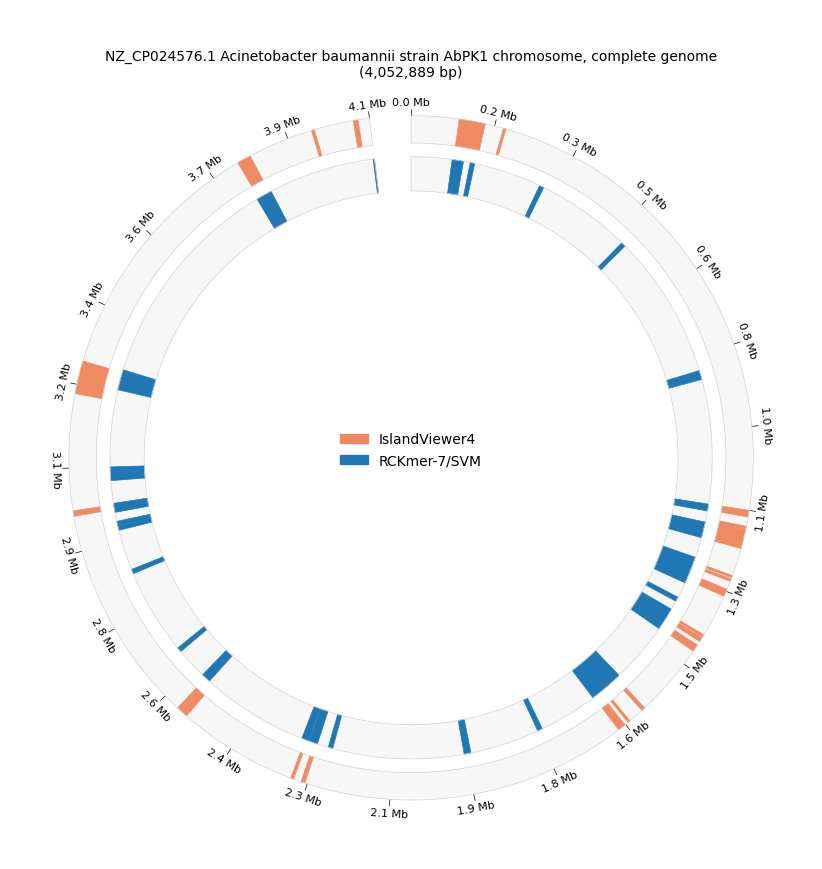

In [46]:
from Bio import SeqIO
from pycirclize import Circos
from matplotlib.patches import Patch

accession_number = "NZ_CP024576.1"   
test_case = "in_species"
fasta_file = f"dataset/genomes/holdout/{test_case}/{accession_number}.fasta"

annotation_files = [
    ("dataset/prev_studies/islandviewer/all_gis_islandviewer_iv4.csv", "IslandViewer4", "#ef8a62"),
    (f"outputs/boundaries_predictions/{test_case}/RCKmer-7_SVM_deduplicated_case3_5_fine_tuned_10000_0.8.xlsx", "RCKmer-7/SVM", "#1f78b4")
]

# Read genome size from FASTA
record = SeqIO.read(fasta_file, "fasta")
genome_size = len(record.seq)
genome_desc = record.description.split('|')[-1]

# Create circos with one sector
circos = Circos({"Genome": genome_size}, space=7)
circos.text(f"{genome_desc}\n({genome_size:,} bp)", r=115)
sector = circos.sectors[0]

# Backbone / axis track
axis_track = sector.add_track((92, 100))
axis_track.axis(fc="#eeeeee", ec="none")
axis_track.xticks_by_interval(
    max(genome_size // 25, 1),
    label_formatter=lambda v: f"{v/1e6:.1f} Mb",
    outer=True,
)

# Define three stacked tracks
track_positions = [
    (92, 100),   # file 1
    (78, 88),   # file 3
]

legend_handles = []

for (excel_file, track_name, color), rlim in zip(annotation_files, track_positions):
    if excel_file.endswith(".csv"):
        df = pd.read_csv(excel_file)
    else:
        df = pd.read_excel(excel_file)
    df.columns = df.columns.str.lower()
    df = df[df['accession']==accession_number]
    #print(len(df),track_name)
    track = sector.add_track(rlim)
    track.axis(fc="#f7f7f7", ec="lightgrey")

    for _, row in df.iterrows():
        start = int(row["start"]) - 1
        end = int(row["end"]) - 1
        track.rect(start, end, fc=color, ec=color, lw=0.5)

    legend_handles.append(Patch(facecolor=color, edgecolor=color, label=track_name))

# Draw and save
fig = circos.plotfig()
fig.legend(
    handles=legend_handles,
    loc="center",
    bbox_to_anchor=(0.5, 0.48),
    frameon=False,
    fontsize=10,
)

### Read predictions on out_phyla test case from the holdout dataset

In [47]:
pred_df = pd.read_excel("outputs/predictions/out_phylum_predicted_gis.xlsx")

In [48]:
tp_df = pred_df[(pred_df['Label']==1)&(pred_df['Predicted_Label']==1)]
fp_df = pred_df[(pred_df['Label']==0)&(pred_df['Predicted_Label']==1)]

In [49]:
## annotate the predicted genomic islands 

from Bio import Entrez
import time

Entrez.email = "your.email@example.com"

def extract_all_functional_zones(accession, start, end):
    handle = Entrez.efetch(
        db="nucleotide", id=accession, seq_start=start, seq_stop=end,
        rettype="gbwithparts", retmode="text"
    )
    record = SeqIO.read(handle, "genbank")
    handle.close()

    time.sleep(0.15)
    
    features_list = []
    
    for feature in record.features:
        if feature.type in ["CDS"]:
            product = "".join(feature.qualifiers.get("product", [])).lower()
            note = "".join(feature.qualifiers.get("note", [])).lower()
            gene = "".join(feature.qualifiers.get("gene", [])).lower()
            
            # Combine text fields to scan them all at once
            all_text = f"{product} {note} {gene}"
            
            # Define classification rules
            if any(k in all_text for k in ["transposase", "integrase", "recombinase", "insertion sequence", "phage", "plasmid","IS"]):
                category = "Mobility"
            elif any(k in all_text for k in ["resistance", "beta-lactamase", "carbapenem","mercury", "arsenic", "biocide", "qac", "efflux","multidrug","drug","dmt","pace","mop","rnd","abc","mfs"]):
                category = "AMR"
            #elif any(k in all_text for k in ["ribosomal protein", "dna polymerase", "gyrase", "rna polymerase", "tnaA"]):
            #    category = "Housekeeping (Core)"
            else:
                category = "Other Functionality"
                
            global_start = int(feature.location.start) + start
            global_end = int(feature.location.end) + start
            
            features_list.append({
                "Gene_Symbol": feature.qualifiers.get("gene", [feature.type])[0],
                "Category": category,
                "Accession": accession,
                "Start": start,
                "End": end,
                "Region_Start": global_start,
                "Region_End": global_end,
                "Product_Description": feature.qualifiers.get("product", [""])[0],
                "Note": feature.qualifiers.get("note", [""])[0]
            })
            
    return pd.DataFrame(features_list)

In [ ]:
from tqdm import tqdm 

# # assign function to each GI
# tp_df_annotated = pd.DataFrame()
# acc_id = tp_df.Accession.unique()

# for acc in tqdm(acc_id):
#     sub_df_regions = tp_df[tp_df['Accession']==acc].reset_index()

#     for idx, row in sub_df_regions.iterrows():
#         #print(f"Analyzing {row['Accession']} ({row['Start']}-{row['End']})...")
#         df_features = extract_all_functional_zones(row['Accession'], row['Start'], row['End'])
#         df_features['GI'] = f'GI_{idx}'

#         tp_df_annotated = pd.concat([tp_df_annotated, df_features])

In [51]:
# read annotated predicted genomic islands 

tp_df_annotated = pd.read_feather("outputs/predictions/out_phylum_tp_annotated.feather")
fp_df_annotated = pd.read_feather("outputs/predictions/out_phylum_fp_annotated.feather")

In [53]:
# get top molecular functions from the true positives and false positives 

top_functions_tp = tp_df_annotated.Product_Description.value_counts().reset_index().head(31).iloc[1:]
top_functions_fp = fp_df_annotated.Product_Description.value_counts().reset_index().head(31).iloc[1:]


top_products_tp_chart = alt.Chart(top_functions_tp).mark_rect().encode(
    y=alt.Y('Product_Description:N', title=None, sort='-color', axis=alt.Axis(labelAngle=0, labelLimit=0)), # Sorts highest count to lowest
    color=alt.Color('count:Q', title='Count', scale=alt.Scale(scheme='greys')),
    tooltip=['Product_Description', 'count']
).properties(
    width=30,
    height=400,
    title='Top molecular functions of True Positives'
)


top_products_fp_chart = alt.Chart(top_functions_fp).mark_rect().encode(
    y=alt.Y('Product_Description:N', title=None, sort='-color', axis=alt.Axis(labelAngle=0, labelLimit=0)), # Sorts highest count to lowest
    color=alt.Color('count:Q', title='Count', scale=alt.Scale(scheme='greys')),
    tooltip=['Product_Description', 'count']
).properties(
    width=30,
    height=400,
    title='Top molecular functions of False Positives'
)

alt.hconcat(top_products_tp_chart, top_products_fp_chart).configure_axis(
    labelFontSize=14
)#.save("top_functions_tp_fp_out_phyla.pdf")

alt.HConcatChart(...)